---
title: "Question1 & 2: Zero-Shot and Few-Shot Prompting in Healthcare"
author: ["Guntas Singh Saran", "Prathmesh Maharshi"]
date: "2025-04-09"
image: "output.png"
format:
    html:
        code-fold: false
        code-tools: true
jupyter: python3
---

In [ ]:
!pip install -U transformers

In [2]:
from transformers import pipeline
import torch
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import pandas as pd
from datasets import load_dataset
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Load Dataset

In [4]:
ds = load_dataset("hpe-ai/medical-cases-classification-tutorial")
ds

README.md:   0%|          | 0.00/192 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


medical_cases_train.csv:   0%|          | 0.00/6.34M [00:00<?, ?B/s]

medical_cases_validation.csv:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

medical_cases_test.csv:   0%|          | 0.00/1.32M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1724 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/370 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/370 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['description', 'transcription', 'sample_name', 'medical_specialty', 'keywords'],
        num_rows: 1724
    })
    validation: Dataset({
        features: ['description', 'transcription', 'sample_name', 'medical_specialty', 'keywords'],
        num_rows: 370
    })
    test: Dataset({
        features: ['description', 'transcription', 'sample_name', 'medical_specialty', 'keywords'],
        num_rows: 370
    })
})

In [5]:
df = pd.DataFrame(ds["train"])
df

,description,transcription,sample_name,medical_specialty,keywords
0,Pacemaker ICD interrogation. Severe nonischem...,"PROCEDURE NOTE: , Pacemaker ICD interrogation....",Pacemaker Interrogation,Cardiovascular / Pulmonary,"cardiovascular / pulmonary, cardiomyopathy, ve..."
1,"Erythema of the right knee and leg, possible s...","PREOPERATIVE DIAGNOSES: , Erythema of the righ...",Aspiration - Knee Joint,Orthopedic,"orthopedic, knee and leg, anterolateral portal..."
2,Left cardiac catheterization with selective ri...,"PREOPERATIVE DIAGNOSIS: , Post infarct angina....",Cardiac Cath & Selective Coronary Angiography,Cardiovascular / Pulmonary,"cardiovascular / pulmonary, selective, angiogr..."
3,Patient with a history of coronary artery dise...,"REASON FOR VISIT: , Acute kidney failure.,HIST...",Acute Kidney Failure,Nephrology,None
4,Cardiac evaluation and treatment in a patient ...,"REASON FOR REFERRAL: , Cardiac evaluation and ...",Cardiac Consultation - 6,Cardiovascular / Pulmonary,None
...,...,...,...,...,...
1719,"Arthroscopy of the left knee, left arthroscopi...","PREOPERATIVE DIAGNOSIS:, Medial meniscal tear...","Arthroscopy, Meniscoplasty, & Chondroplasty",Orthopedic,"orthopedic, medial meniscoplasty, arthroscopic..."
1720,Normal awake and drowsy (stage I sleep) EEG fo...,"DESCRIPTION OF RECORD: ,This tracing was obta...",Electroencephalogram,Neurology,"neurology, gold-plated surface disc electrodes..."
1721,MRI of the brain without contrast to evaluate ...,"EXAM: , MRI of the brain without contrast.,HIS...",MRI of Brain w/o Contrast.,Neurology,"neurology, mri, diffusion, posterior fossa, ax..."
1722,The patient comes for three-week postpartum ch...,"CHIEF COMPLAINT:, The patient comes for three...",Three-Week Postpartum Checkup,Obstetrics / Gynecology,"obstetrics / gynecology, checkup, allergies, p..."


# Get the Unique Classes of `medical_speciality`

In [6]:
cls = [df.loc[i, "medical_specialty"] for i in range(len(df))]
classes = list(set(cls))
classes, len(classes)

(['Hematology - Oncology',
  'Radiology',
  'Gastroenterology',
  'Neurology',
  'Nephrology',
  'Neurosurgery',
  'Cardiovascular / Pulmonary',
  'Orthopedic',
  'Obstetrics / Gynecology',
  'ENT - Otolaryngology',
  'Psychiatry / Psychology',
  'Ophthalmology',
  'Pediatrics - Neonatal'],
 13)

# Load the Model using `huggingface` `pipeline`

In [ ]:
!huggingface-cli login --token <TOKEN>

In [8]:
model = "google/gemma-3-1b-it"
classifier = pipeline("text-generation", model=model)

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

Device set to use cuda:0


In [9]:
cls_str = ", ".join(classes)
cls_str

'Hematology - Oncology, Radiology, Gastroenterology, Neurology, Nephrology, Neurosurgery, Cardiovascular / Pulmonary, Orthopedic, Obstetrics / Gynecology, ENT - Otolaryngology, Psychiatry / Psychology, Ophthalmology, Pediatrics - Neonatal'

# Zero-Shot Prompt Template

In [10]:
prompt_template = """
You are a medical expert tasked with classifying a disease description into one of these medical specialties: {cls_str}. Analyze the description carefully, focusing on symptoms, conditions, and medical terms. Select the most appropriate specialty from the list and output ONLY the specialty name inside brackets, like [Specialty Name]. Do not repeat the prompt or add extra text—just the prediction in this format: [Specialty Name].

Description: {description}

Predicted Medical Specialty: 
"""

# Demo of the workflow ahead

In [11]:
dscrp = df.loc[285, "description"]
tr_cls = df.loc[285, "medical_specialty"]
print(tr_cls)
print("="*50)
prompt = prompt_template.format(cls_str=cls_str, description=dscrp)
result = classifier(prompt, max_new_tokens=20, do_sample=False)[0]['generated_text']
print(result)
generated_text = result[len(prompt):].strip()
pred_specialty = generated_text.split("[")[1].split("]")[0].strip()
print("="*50)
print(pred_specialty)

Cardiovascular / Pulmonary


/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.95` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:653: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `64` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(



You are a medical expert tasked with classifying a disease description into one of these medical specialties: Hematology - Oncology, Radiology, Gastroenterology, Neurology, Nephrology, Neurosurgery, Cardiovascular / Pulmonary, Orthopedic, Obstetrics / Gynecology, ENT - Otolaryngology, Psychiatry / Psychology, Ophthalmology, Pediatrics - Neonatal. Analyze the description carefully, focusing on symptoms, conditions, and medical terms. Select the most appropriate specialty from the list and output ONLY the specialty name inside brackets, like [Specialty Name]. Do not repeat the prompt or add extra text—just the prediction in this format: [Specialty Name].

Description: Problem of essential hypertension.  Symptoms that suggested intracranial pathology.

Predicted Medical Specialty: 
[Neurology]

Explanation: The description mentions "essential hypertension" (high blood pressure) and
Neurology


# Classical Way: Slow

In [12]:
# df = pd.DataFrame(ds["test"])

In [13]:
# true_labels = []
# pred_labels = []

# for index, row in tqdm(df.iterrows()):
#     description = row["description"]
#     true_label = row["medical_specialty"]
#     true_labels.append(true_label)
    
#     prompt = prompt_template.format(cls_str=cls_str, description=description)
#     result = classifier(prompt, max_new_tokens=10, do_sample=False)[0]['generated_text']
#     generated_text = result[len(prompt):].strip()
#     pred_specialty = generated_text.split("[")[1].split("]")[0].strip() if "[" in generated_text else generated_text
#     pred_labels.append(pred_specialty)

In [14]:
# precision, recall, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average="weighted", zero_division=0)
# conf_matrix = confusion_matrix(true_labels, pred_labels, labels=classes)

# print(f"\nFew-Shot Learning Metrics ({num_shots} Shots):")
# print(f"Precision: {precision:.3f}")
# print(f"Recall: {recall:.3f}")
# print(f"F1 Score: {f1:.3f}")
# print("Confusion Matrix:")
# print(conf_matrix)

# Optimised Way: Applying Maps over `datasets`

In [15]:
classifier = pipeline("text-generation", model=model, device=0, batch_size=16)

Device set to use cuda:0


In [16]:
dataset = ds["test"]

In [17]:
def format_prompts(example):
    example["prompt"] = prompt_template.format(cls_str=cls_str, description=example["description"])
    example["true_label"] = example["medical_specialty"]
    return example

dataset = dataset.map(format_prompts)

Map:   0%|          | 0/370 [00:00<?, ? examples/s]

In [18]:
def predict_batch(examples):
    prompts = examples["prompt"]
    results = classifier(prompts, max_new_tokens=10, do_sample=False)
    predictions = [result[0]["generated_text"][len(prompt):].strip() for prompt, result in zip(prompts, results)]
    examples["prediction"] = [pred.split("[")[1].split("]")[0].strip() if "[" in pred else pred for pred in predictions]
    return examples

dataset = dataset.map(predict_batch, batched=True, batch_size=16)

Map:   0%|          | 0/370 [00:00<?, ? examples/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Zero-Shot Learning Metrics:
Precision: 0.613
Recall: 0.414
F1 Score: 0.421
Confusion Matrix:


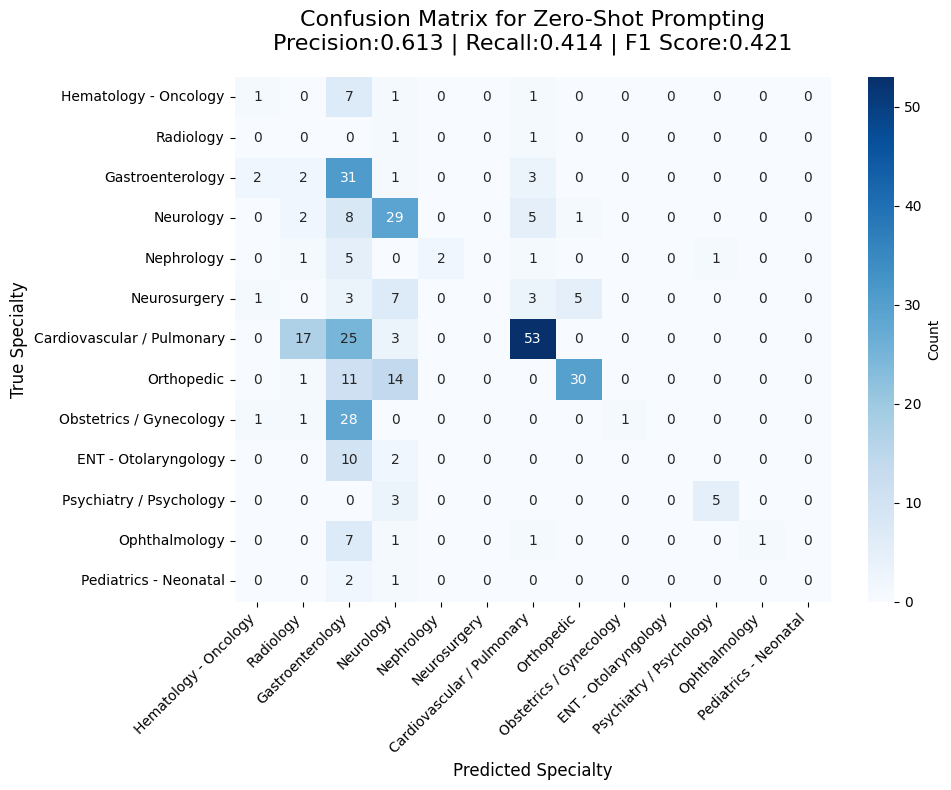

In [19]:
df_results = dataset.to_pandas()

true_labels = df_results["true_label"].tolist()
pred_labels = df_results["prediction"].tolist()

precision, recall, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average="weighted", zero_division=0)
conf_matrix = confusion_matrix(true_labels, pred_labels, labels=classes)

print("Zero-Shot Learning Metrics:")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print("Confusion Matrix:")
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=classes, yticklabels=classes, 
            cbar_kws={'label': 'Count'})
plt.title(f"Confusion Matrix for Zero-Shot Prompting\nPrecision:{precision:.3f} | Recall:{recall:.3f} | F1 Score:{f1:.3f}", fontsize=16, pad=20)
plt.xlabel("Predicted Specialty", fontsize=12)
plt.ylabel("True Specialty", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
for tr, pr in zip(true_labels, pred_labels):
    print((tr, pr))

('Orthopedic', 'Neurology')
('Cardiovascular / Pulmonary', 'Gastroenterology')
('Cardiovascular / Pulmonary', 'Cardiovascular / Pulmonary')
('Orthopedic', 'Neurology')
('Neurology', 'Neurology')
('ENT - Otolaryngology', 'Gastroenterology')
('Neurology', 'Neurology')
('Gastroenterology', 'Gastroenterology')
('Cardiovascular / Pulmonary', 'Cardiovascular / Pulmonary')
('Gastroenterology', 'Hematology - Oncology')
('Obstetrics / Gynecology', 'Gastroenterology')
('Cardiovascular / Pulmonary', 'Radiology')
('Cardiovascular / Pulmonary', 'Cardiovascular / Pulmonary')
('Orthopedic', 'Orthopedic')
('Cardiovascular / Pulmonary', 'Cardiovascular / Pulmonary')
('Neurology', 'Neurology')
('Obstetrics / Gynecology', 'Gastroenterology')
('Cardiovascular / Pulmonary', 'Cardiovascular / Pulmonary')
('Neurology', 'Gastroenterology')
('Neurosurgery', 'Gastroenterology')
('Orthopedic', 'Neurology')
('Cardiovascular / Pulmonary', 'Gastroenterology')
('Cardiovascular / Pulmonary', 'Gastroenterology')
('Obs

# Few-Shot Prompting

In [21]:
few_shot_template = """
You are a medical expert classifying disease descriptions into medical specialties. Below are {num_shots} randomly selected examples to guide you. Each example includes a description and its medical specialty. Based on these examples, classify the new description into one of these specialties: {cls_str}. Analyze the new description by comparing it to the examples, focusing on symptoms, conditions, and medical terms. Output ONLY the specialty name inside brackets, like [Specialty Name]. Do not repeat the prompt or add extra text—just the prediction in this format: [Specialty Name].

Examples:
{examples}

New Description: {description}

Predicted Medical Specialty:
"""

In [22]:
dataset_train = ds["train"]
dataset_test = ds["test"]

# Generate Random Examples of a superset of Unique Labels atleast

In [23]:
def create_random_examples(dataset, num_shots):
    # indices = np.random.choice(len(dataset), min(num_shots, len(dataset)), replace=False)
    # examples = ""
    # for i, idx in enumerate(indices, 1):
    #     row = dataset[int(idx)]
    #     examples += f"{i}. Description: {row['description']}\n   Medical Specialty: {row['medical_specialty']}\n"
    # return examples
    df = pd.DataFrame(dataset)
    unique_labels = df["medical_specialty"].unique()
    num_unique = len(unique_labels)
    
    selected_indices = []
    for label in unique_labels:
        if len(selected_indices) >= num_shots:
            break
        label_indices = df[df["medical_specialty"] == label].index.tolist()
        selected_indices.append(np.random.choice(label_indices))
    
    if num_shots > num_unique:
        remaining = num_shots - num_unique
        additional_indices = np.random.choice(len(dataset), remaining, replace=True)
        selected_indices.extend(additional_indices)
    
    selected_indices = selected_indices[:num_shots]
    
    examples = ""
    for i, idx in enumerate(selected_indices, 1):
        row = dataset[int(idx)]
        examples += f"{i}. Description:\n{row['description']}\nMedical Specialty:\n{row['medical_specialty']}\n\n"
    return examples

# Example Workflow

In [24]:
num_shots = 10
exs = create_random_examples(dataset_train, num_shots)
print(exs)

1. Description:
Chest tube talc pleurodesis of the right chest.
Medical Specialty:
Cardiovascular / Pulmonary

2. Description:
Repeat irrigation and debridement of Right distal femoral subperiosteal abscess.
Medical Specialty:
Orthopedic

3. Description:
Acute renal failure, suspected, likely due to multi-organ system failure syndrome.
Medical Specialty:
Nephrology

4. Description:
Artificial rupture of membrane was performed for clear fluid.  She did receive epidural anesthesia.  She progressed to complete and pushing.
Medical Specialty:
Obstetrics / Gynecology

5. Description:
Pars plana vitrectomy, pars plana lensectomy, exploration of exit wound, closure of perforating corneal scleral laceration involving uveal tissue, air-fluid exchange, C3F8 gas, and scleral buckling, right eye.
Medical Specialty:
Ophthalmology

6. Description:
Esophagoscopy with removal of foreign body.   Esophageal foreign body, no associated comorbidities are noted.
Medical Specialty:
Gastroenterology

7. Desc

In [25]:
df_test = pd.DataFrame(dataset_test)
dscrp = df_test.loc[54, "description"]
tr_cls = df_test.loc[54, "medical_specialty"]
print(tr_cls)
print("="*50)
prompt = few_shot_template.format(num_shots=num_shots, cls_str=cls_str, examples=exs, description=dscrp)
result = classifier(prompt, max_new_tokens=10, do_sample=False)[0]['generated_text']
print(result)
intermed_result = result[len(prompt):]
generated_text = intermed_result.strip().split("\n")[0] if "\n" in intermed_result else intermed_result.strip()
pred_specialty = generated_text.split("[")[1].split("]")[0].strip() if "[" in generated_text else generated_text
print("="*50)
print(pred_specialty)

Cardiovascular / Pulmonary


/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.95` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:653: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `64` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(



You are a medical expert classifying disease descriptions into medical specialties. Below are 10 randomly selected examples to guide you. Each example includes a description and its medical specialty. Based on these examples, classify the new description into one of these specialties: Hematology - Oncology, Radiology, Gastroenterology, Neurology, Nephrology, Neurosurgery, Cardiovascular / Pulmonary, Orthopedic, Obstetrics / Gynecology, ENT - Otolaryngology, Psychiatry / Psychology, Ophthalmology, Pediatrics - Neonatal. Analyze the new description by comparing it to the examples, focusing on symptoms, conditions, and medical terms. Output ONLY the specialty name inside brackets, like [Specialty Name]. Do not repeat the prompt or add extra text—just the prediction in this format: [Specialty Name].

Examples:
1. Description:
Chest tube talc pleurodesis of the right chest.
Medical Specialty:
Cardiovascular / Pulmonary

2. Description:
Repeat irrigation and debridement of Right distal femo

In [26]:
def format_few_shot_prompts(examples_str, num_shots):
    def _format(example):
        example["prompt"] = few_shot_template.format(num_shots=num_shots, cls_str=cls_str, examples=examples_str, description=example["description"])
        example["true_label"] = example["medical_specialty"]
        return example
    return _format

In [27]:
def predict_batch(examples):
    prompts = examples["prompt"]
    results = classifier(prompts, max_new_tokens=10, do_sample=False)
    predictions = [result[0]["generated_text"][len(prompt):].strip().split("\n")[0] if "\n" in result[0]["generated_text"][len(prompt):] else result[0]["generated_text"][len(prompt):].strip() for prompt, result in zip(prompts, results)]
    examples["prediction"] = [pred.split("[")[1].split("]")[0].strip() if "[" in pred else pred for pred in predictions]
    return examples

Map:   0%|          | 0/370 [00:00<?, ? examples/s]

Map:   0%|          | 0/370 [00:00<?, ? examples/s]


Few-Shot Learning Metrics (15 Shots):
Precision: 0.769
Recall: 0.557
F1 Score: 0.607
Confusion Matrix:
[[11  2  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  1  0  0  0  0  1  0  0  0  0  0  0]
 [12  1 17  0  1  0  0  0  0  0  0  0  0]
 [ 7  3  0 29  1  2  2  2  0  0  1  0  0]
 [ 1  0  0  0  6  0  1  0  0  0  1  0  0]
 [ 2  0  0  5  1  1  2  8  0  0  0  0  0]
 [ 9  7  0  3  0  2 71  0  0  0  0  1  0]
 [ 2  1  0 11  0  0  1 39  0  0  0  0  0]
 [15  0  0  0  0  0  0  0 10  0  0  2  0]
 [ 0  0  0  3  0  0  1  2  0  3  0  0  0]
 [ 0  0  0  1  0  0  0  0  0  0  8  0  0]
 [ 0  0  0  1  0  0  0  0  0  0  0  9  0]
 [ 0  0  0  0  0  0  1  0  0  0  0  0  1]]


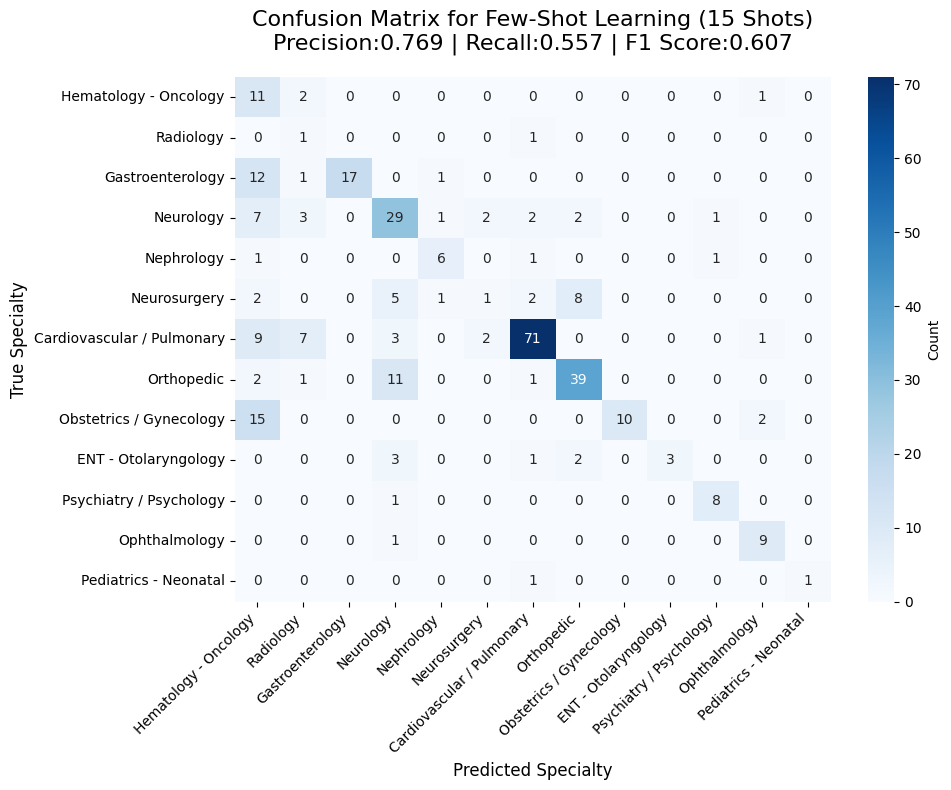

In [28]:
# shot_counts = [10, 15, 20]
num_shots = 15

# for num_shots in shot_counts:
# provide train dataset examples for few-shot
examples_str = create_random_examples(dataset_train, num_shots)

# infer on the test dataset
formatted_dataset = dataset_test.map(format_few_shot_prompts(examples_str, num_shots))

formatted_dataset = formatted_dataset.map(predict_batch, batched=True, batch_size=16)

df_results = formatted_dataset.to_pandas()

true_labels = df_results["true_label"].tolist()
pred_labels = df_results["prediction"].tolist()

precision, recall, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average="weighted", zero_division=0)
conf_matrix = confusion_matrix(true_labels, pred_labels, labels=classes)

print(f"\nFew-Shot Learning Metrics ({num_shots} Shots):")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print("Confusion Matrix:")
print(conf_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=classes, yticklabels=classes, 
            cbar_kws={'label': 'Count'})
plt.title(f"Confusion Matrix for Few-Shot Learning ({num_shots} Shots)\nPrecision:{precision:.3f} | Recall:{recall:.3f} | F1 Score:{f1:.3f}", fontsize=16, pad=20)
plt.xlabel("Predicted Specialty", fontsize=12)
plt.ylabel("True Specialty", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
torch.cuda.synchronize()

In [30]:
torch.cuda.empty_cache()

In [31]:
for tr, pr in zip(true_labels, pred_labels):
    print((tr, pr))

('Orthopedic', 'Orthopedic')
('Cardiovascular / Pulmonary', 'Cardiovascular / Pulmonary')
('Cardiovascular / Pulmonary', 'Cardiovascular / Pulmonary')
('Orthopedic', 'Orthopedic')
('Neurology', 'Hematology - Oncology')
('ENT - Otolaryngology', 'ENT - Otolaryngology')
('Neurology', 'Neurology')
('Gastroenterology', 'Hematology - Oncology')
('Cardiovascular / Pulmonary', 'Cardiovascular / Pulmonary')
('Gastroenterology', 'Hematology - Oncology')
('Obstetrics / Gynecology', 'Gynecology')
('Cardiovascular / Pulmonary', 'Cardiovascular / Pulmonary')
('Cardiovascular / Pulmonary', 'Cardiovascular / Pulmonary')
('Orthopedic', 'Orthopedic')
('Cardiovascular / Pulmonary', 'Cardiovascular / Pulmonary')
('Neurology', 'Psychiatry / Psychology')
('Obstetrics / Gynecology', 'Obstetrics / Gynecology')
('Cardiovascular / Pulmonary', 'Cardiovascular / Pulmonary')
('Neurology', 'Hematology - Oncology')
('Neurosurgery', 'Nephrology')
('Orthopedic', 'Neurology')
('Cardiovascular / Pulmonary', 'Pulmonary /